In [2]:
!pip install numpy matplotlib tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

In [4]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training Images Shape:", x_train.shape)
print("Training Labels Shape:", y_train.shape)

print("Testing Images Shape:", x_test.shape)
print("Testing Labels Shape:", y_test.shape)

Training Images Shape: (60000, 28, 28)
Training Labels Shape: (60000,)
Testing Images Shape: (10000, 28, 28)
Testing Labels Shape: (10000,)


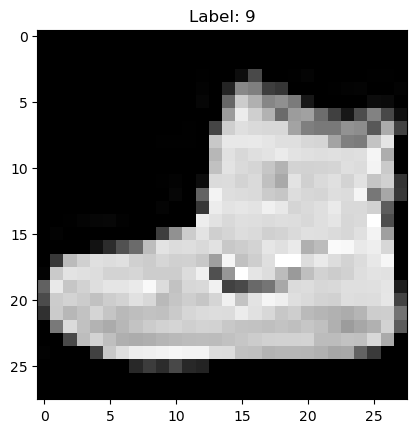

In [5]:
plt.imshow(x_train[0], cmap='gray')
plt.title("Label: " + str(y_train[0]))
plt.show()

In [6]:
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Normalization Done")

Normalization Done


In [7]:
class ConvLayer:

    def __init__(self, num_filters):

        self.num_filters = num_filters

        self.filters = np.random.randn(num_filters, 3, 3) / 9

    def iterate_regions(self, image):

        h, w = image.shape

        for i in range(h - 2):
            for j in range(w - 2):

                region = image[i:(i + 3), j:(j + 3)]

                yield region, i, j

    def forward(self, input):

        self.last_input = input

        h, w = input.shape

        output = np.zeros((h - 2, w - 2, self.num_filters))

        for region, i, j in self.iterate_regions(input):

            output[i, j] = np.sum(region * self.filters, axis=(1, 2))

        return output

In [8]:
class MaxPool:

    def iterate_regions(self, image):

        h, w, num_filters = image.shape

        new_h = h // 2
        new_w = w // 2

        for i in range(new_h):
            for j in range(new_w):

                region = image[(i * 2):(i * 2 + 2),
                               (j * 2):(j * 2 + 2)]

                yield region, i, j

    def forward(self, input):

        self.last_input = input

        h, w, num_filters = input.shape

        output = np.zeros((h // 2, w // 2, num_filters))

        for region, i, j in self.iterate_regions(input):

            output[i, j] = np.amax(region, axis=(0, 1))

        return output

In [9]:
class Softmax:

    def __init__(self, input_len, nodes):

        self.weights = np.random.randn(input_len, nodes) / input_len

        self.biases = np.zeros(nodes)

    def forward(self, input):

        self.last_input_shape = input.shape

        input = input.flatten()

        self.last_input = input

        totals = np.dot(input, self.weights) + self.biases

        exp = np.exp(totals)

        return exp / np.sum(exp)

In [10]:
conv = ConvLayer(8)

pool = MaxPool()

softmax = Softmax(13 * 13 * 8, 10)

In [11]:
def forward(image, label):

    out = conv.forward(image)

    out = pool.forward(out)

    out = softmax.forward(out)

    loss = -np.log(out[label])

    acc = 1 if np.argmax(out) == label else 0

    return out, loss, acc

In [12]:
out, loss, acc = forward(x_train[0], y_train[0])

print("Loss:", loss)

print("Accuracy:", acc)

Loss: 2.3030964184370935
Accuracy: 0


In [13]:
print("CNN Training Started")

for epoch in range(3):

    print("Epoch:", epoch + 1)

    loss = 0
    num_correct = 0

    for i, (image, label) in enumerate(zip(x_train[:1000], y_train[:1000])):

        _, l, acc = forward(image, label)

        loss += l
        num_correct += acc

        if i % 100 == 99:

            print(
                "Step:",
                i + 1,
                "Average Loss:",
                loss / 100,
                "Accuracy:",
                num_correct
            )

            loss = 0
            num_correct = 0

CNN Training Started
Epoch: 1
Step: 100 Average Loss: 2.3025117584879298 Accuracy: 16
Step: 200 Average Loss: 2.302429726760646 Accuracy: 13
Step: 300 Average Loss: 2.3019275215328125 Accuracy: 19
Step: 400 Average Loss: 2.3026384315410193 Accuracy: 15
Step: 500 Average Loss: 2.3028050367489517 Accuracy: 7
Step: 600 Average Loss: 2.302124068607142 Accuracy: 18
Step: 700 Average Loss: 2.3032228698872252 Accuracy: 8
Step: 800 Average Loss: 2.3024699373294415 Accuracy: 7
Step: 900 Average Loss: 2.303170904773666 Accuracy: 14
Step: 1000 Average Loss: 2.301903548950987 Accuracy: 18
Epoch: 2
Step: 100 Average Loss: 2.3025117584879298 Accuracy: 16
Step: 200 Average Loss: 2.302429726760646 Accuracy: 13
Step: 300 Average Loss: 2.3019275215328125 Accuracy: 19
Step: 400 Average Loss: 2.3026384315410193 Accuracy: 15
Step: 500 Average Loss: 2.3028050367489517 Accuracy: 7
Step: 600 Average Loss: 2.302124068607142 Accuracy: 18
Step: 700 Average Loss: 2.3032228698872252 Accuracy: 8
Step: 800 Average L

In [14]:
correct = 0

for image, label in zip(x_test[:100], y_test[:100]):

    _, _, acc = forward(image, label)

    correct += acc

print("Test Accuracy:", correct, "%")

Test Accuracy: 15 %
